<a href="https://colab.research.google.com/github/aflahbisnis29-commits/uts-bigdata-Aflahul-Aziz-14022300057/blob/main/uts-aflahul-aziz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
!pip install google-play-scraper transformers


In [ ]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.cilegon.simapan',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=58,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 58 ulasan ke 'ulasan_google_play.csv'


In [ ]:
pip install transformers


In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(filename)

# Display the first few rows to confirm data loading
print("Data loaded successfully:")
display(df.head())

Data loaded successfully:


,userName,score,at,content
0,Usaha Seblak,1,2026-03-11 13:59:11,baru di kasih tau sama dewan atau ibu Aulia Ku...
1,FA GAMING,5,2026-03-09 15:51:35,terimakasih Cilegon juare sangat sangat memban...
2,Marzaqi chanel,2,2026-03-09 04:57:23,ore bise masuk gagal bae
3,Warsito,5,2026-03-09 01:42:41,"Apk nya cukup bagus, cuman sayang hampura bang..."
4,Siswan Toro,2,2026-03-09 00:01:58,blm bisa log in... udah masuk KTP n WA email b...


In [ ]:
# Load pre-trained Indo RoBERTa sentiment model and tokenizer
model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Map model output labels to readable sentiment labels
# The model 'w11wo/indonesian-roberta-base-sentiment-classifier' typically outputs 0: positive, 1: neutral, 2: negative
label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}

# Function to predict sentiment for a given text
def get_sentiment(text):
    if pd.isna(text): # Handle NaN values in text column
        return 'N/A'
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)
    predicted_class_id = torch.argmax(probabilities, dim=1).item()
    return label_map[predicted_class_id]

# Apply sentiment analysis to the 'content' column
df['sentiment'] = df['content'].apply(get_sentiment)

print("Sentiment analysis complete. Displaying results:")
display(df[['content', 'sentiment']].head(10))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentiment analysis complete. Displaying results:


,content,sentiment
0,baru di kasih tau sama dewan atau ibu Aulia Ku...,negative
1,terimakasih Cilegon juare sangat sangat memban...,positive
2,ore bise masuk gagal bae,negative
3,"Apk nya cukup bagus, cuman sayang hampura bang...",negative
4,blm bisa log in... udah masuk KTP n WA email b...,neutral
5,gjelas bnget ni aplikasi suruh masukin passwor...,negative
6,tolong dong pas daftar di menu untuk isi data ...,negative
7,aplikasi APA ini susah amat mau login daftar n...,negative
8,"login nya lumayan susah, error system",negative
9,keren,positive


/tmp/ipykernel_9398/3838574864.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


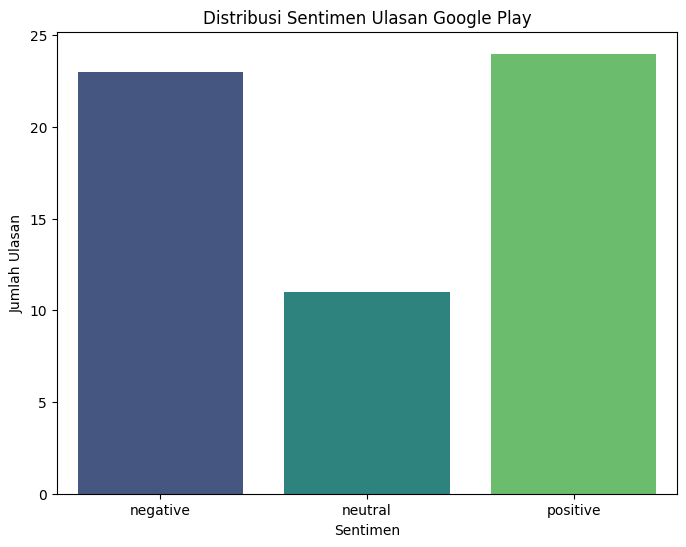

Ringkasan distribusi sentimen:


,count
sentiment,
negative,23
neutral,11
positive,24


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = df['sentiment'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribusi Sentimen Ulasan Google Play')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

print("Ringkasan distribusi sentimen:")
display(sentiment_counts)

## Tutorial: Memindahkan Colab Notebook ke GitHub dan Membukanya Kembali

Ikuti langkah-langkah di bawah ini untuk menyimpan notebook Colab Anda ke GitHub dan kemudian membukanya kembali dari GitHub.

### Bagian 1: Menyimpan Notebook Colab ke GitHub

1.  **Pastikan Anda Sudah Login ke GitHub**:
    *   Buka browser Anda dan pastikan Anda sudah login ke akun GitHub Anda.

2.  **Buka Notebook Colab Anda**:
    *   Buka notebook Colab yang sedang Anda kerjakan dan ingin Anda simpan ke GitHub.

3.  **Simpan Salinan ke GitHub**:
    *   Di menu Colab, klik **File**.
    *   Pilih **Save a copy in GitHub...**.

4.  **Otorisasi GitHub (Jika Diminta)**:
    *   Jika ini pertama kalinya Anda menyimpan ke GitHub dari Colab, Anda mungkin akan diminta untuk mengotorisasi Colab untuk mengakses akun GitHub Anda. Ikuti petunjuk untuk memberikan otorisasi.

5.  **Pilih Repository dan Nama File**:
    *   Setelah otorisasi, sebuah jendela pop-up akan muncul.
    *   **Repository**: Pilih repositori GitHub tempat Anda ingin menyimpan notebook tersebut. Anda bisa memilih repositori yang sudah ada atau membuat yang baru di GitHub terlebih dahulu.
    *   **File path**: Anda bisa menentukan folder di dalam repositori tempat file akan disimpan (misalnya, `notebooks/nama_notebook_anda.ipynb`). Jika Anda tidak menentukan, itu akan disimpan di root repositori.
    *   **Include a link to Colab**: Biarkan opsi ini dicentang. Ini akan menambahkan lencana (badge) di bagian atas notebook di GitHub yang memungkinkan Anda membukanya langsung di Colab dengan satu klik.
    *   Klik **OK**.

6.  **Verifikasi di GitHub**:
    *   Setelah proses selesai, Anda akan melihat notifikasi bahwa notebook telah disimpan.
    *   Buka repositori GitHub Anda di browser. Anda akan melihat file `.ipynb` yang baru ditambahkan.

### Bagian 2: Membuka Notebook dari GitHub di Colab

Ada beberapa cara untuk membuka notebook yang sudah tersimpan di GitHub kembali ke Colab:

#### Metode 1: Menggunakan Tautan Langsung dari GitHub (Paling Mudah)

1.  **Buka Notebook di GitHub**:
    *   Navigasikan ke repositori GitHub Anda dan klik pada file `.ipynb` yang ingin Anda buka.

2.  **Klik Tombol 'Open in Colab'**:
    *   Di bagian atas tampilan notebook di GitHub (jika Anda mencentang 'Include a link to Colab' saat menyimpan), Anda akan melihat lencana "Open in Colab". Klik lencana tersebut.
    *   Notebook akan terbuka langsung di Google Colab.

#### Metode 2: Melalui Google Colab

1.  **Buka Google Colab**:
    *   Pergi ke [colab.research.google.com](https://colab.research.google.com).

2.  **Buka dari GitHub**:
    *   Klik **File** > **Open notebook**.
    *   Pada jendela pop-up, pilih tab **GitHub**.

3.  **Cari Repositori Anda**:
    *   Anda dapat mencari repositori Anda berdasarkan nama pengguna/organisasi GitHub Anda atau menempelkan URL repositori.
    *   Pilih repositori dan kemudian pilih file `.ipynb` yang ingin Anda buka.
    *   Klik **Open**.

Notebook Anda sekarang akan terbuka di Google Colab, siap untuk diedit atau dijalankan kembali.